# PyTorch for Education Analytics: Theory & Hands-On Projects

A complete, self-contained notebook that teaches PyTorch fundamentals — tensors, autograd, and full training pipelines — and applies every concept to a **trending topic in the education sector: learning analytics for student success and retention.**

Education systems worldwide are turning to AI/ML to spot at-risk students early, personalize learning paths, and predict outcomes before it's too late to intervene. This notebook builds that pipeline from first principles.

**Contents**
1. What is PyTorch? (quick refresher)
2. Tensors: Theory & Creation — using student-record data
3. Mathematical Operations on Tensors — computing academic statistics
4. Shapes, Reshaping & Dimensions — batching student records
5. Autograd: Gradients in PyTorch
6. Project 1 — Linear Regression: Predicting Final Exam Scores
7. Datasets & DataLoaders — a Student Performance dataset
8. Building a Neural Network (`nn.Module`)
9. Project 2 — **Student Dropout Prediction** (binary classification)
10. Project 3 — Challenge: **Student Performance-Level Classification** (Low / Medium / High)
11. Wrap-up & Key Takeaways


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.14.0+cu130
CUDA available: False


## 1. What is PyTorch? (Quick Refresher)

**PyTorch** is a Python-based, open-source deep learning library built around:

1. **Dynamic computation graphs** — the graph is built on the fly as operations run ("define-by-run"), making it easy to debug and experiment.
2. **Tensors with GPU acceleration** — NumPy-like arrays that can run on GPU via `.to('cuda')`.
3. **`torch.nn`** — ready-made layers and loss functions, assembled into custom `nn.Module` subclasses.
4. **Autograd** — automatic differentiation: PyTorch tracks every tensor operation and computes gradients for you.
5. **A rich ecosystem** for research and production.

### Why education analytics?

**Trending topic: AI-driven student retention & personalized learning.** Universities and EdTech platforms increasingly mine **learning-management-system (LMS) data** — attendance, engagement, grades, study habits — to:

- Predict which students are **at risk of dropping out**, early enough to intervene.
- Forecast **exam performance** from study behavior, so students and advisors can course-correct.
- Segment students into **performance tiers** to route them to the right level of support or challenge (personalized/adaptive learning).

Every technique below (tensors → autograd → training loop → evaluation) is the same machinery used by real learning-analytics systems — we're just applying it to representative student data.

### The PyTorch workflow (unchanged, regardless of domain)

1. Define your model by subclassing `torch.nn.Module`.
2. Prepare `DataLoader`s to feed input batches.
3. Choose an optimizer (`SGD`, `Adam`) and a loss function.
4. Run a training loop: forward pass → compute loss → `.backward()` → update parameters.


## 2. Tensors: Theory & Creation

A **tensor** organizes numbers along one or more axes:

- **Scalar (0D)** — e.g. a single student's GPA: `3.7`
- **Vector (1D)** — e.g. one student's feature row: `[study_hours, attendance, gpa]`
- **Matrix (2D)** — e.g. a whole *class* of students: rows = students, columns = features
- **Higher-D tensor (3D+)** — e.g. weekly engagement logs per student per week: (students, weeks, features)

PyTorch tensors behave like NumPy arrays (same indexing/slicing) but add **GPU acceleration** and **autograd** integration — exactly what we need to train models on student data.


In [2]:
# A single student's feature vector: [study_hours_per_week, attendance_pct, gpa]
student = torch.tensor([12.5, 87.0, 3.4])
print("Student vector:", student, "| shape:", student.shape)

# A small "class" of 4 students (2D tensor: rows=students, cols=features)
classroom = torch.tensor([
    [12.5, 87.0, 3.4],
    [3.0,  60.0, 2.1],
    [18.0, 95.0, 3.9],
    [7.5,  74.0, 2.8],
])
print("\nClassroom matrix:\n", classroom)
print("shape:", classroom.shape)  # (4 students, 3 features)


Student vector: 

tensor([12.5000, 87.0000,  3.4000]) | shape: torch.Size([3])

Classroom matrix:
 tensor([[12.5000, 87.0000,  3.4000],
        [ 3.0000, 60.0000,  2.1000],
        [18.0000, 95.0000,  3.9000],
        [ 7.5000, 74.0000,  2.8000]])
shape: torch.Size([4, 3])


In [3]:
# --- Practical task: build a 3D tensor directly (no intermediate variable) ---
# Weekly LMS engagement logs for 2 students, 3 weeks, 2 metrics: [logins, minutes_active]
engagement_3d = torch.tensor([
    [[5, 120], [3, 80], [7, 200]],   # student 1, weeks 1-3
    [[1, 20],  [2, 45], [0, 0]],     # student 2, weeks 1-3
])
print(engagement_3d)
print("shape:", engagement_3d.shape)  # (2 students, 3 weeks, 2 metrics)


tensor([[[  5, 120],
         [  3,  80],
         [  7, 200]],

        [[  1,  20],
         [  2,  45],
         [  0,   0]]])
shape: torch.Size([2, 3, 2])


### Built-in tensor-creation functions

| Function | Produces | Education-analytics use |
|---|---|---|
| `torch.zeros(*size)` | All zeros | Placeholder for a new cohort's scores before grading |
| `torch.ones(*size)` | All ones | Neutral weighting vector |
| `torch.arange(start,end,step)` | Regular sequence (end exclusive) | Week numbers in a semester |
| `torch.linspace(start,end,steps)` | Evenly spaced values (inclusive) | A grading curve or percentile grid |
| `torch.rand` / `torch.randn` / `torch.randint` | Random values | Initializing model weights |


In [4]:
# Zeros = a placeholder gradebook for 5 students x 3 assignments (not yet graded)
gradebook_placeholder = torch.zeros(5, 3)
print("Empty gradebook:\n", gradebook_placeholder)

# arange: week numbers 1..15 of a semester
weeks = torch.arange(1, 16)
print("\nSemester weeks:", weeks)

# linspace: a 0-100 percentile grid with 11 points, for a grading curve
percentile_grid = torch.linspace(0, 100, steps=11)
print("\nPercentile grid:", percentile_grid)


Empty gradebook:
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

Semester weeks: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

Percentile grid: tensor([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.])


In [5]:
torch.manual_seed(42)

# --- Practical challenge: initializing weights/biases for a small NN, education-flavored ---
# Layer 1: maps 4 student features -> 6 hidden units
weights_layer1 = torch.rand(4, 6)          # uniform [0,1) init (didactic; real nets use Xavier/He)
biases_layer1  = torch.zeros(1, 6)         # zero-initialized biases
weights_layer2 = torch.randint(-5, 6, (6, 2))  # toy integer weights, layer 2 (2 outputs: at-risk / not)

print("Weights layer 1:\n", weights_layer1)
print("Biases layer 1:\n", biases_layer1)
print("Weights layer 2:\n", weights_layer2)


Weights layer 1:
 tensor([[0.8823, 0.9150, 0.3829, 0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408, 0.1332, 0.9346, 0.5936],
        [0.8694, 0.5677, 0.7411, 0.4294, 0.8854, 0.5739],
        [0.2666, 0.6274, 0.2696, 0.4414, 0.2969, 0.8317]])
Biases layer 1:
 tensor([[0., 0., 0., 0., 0., 0.]])
Weights layer 2:
 tensor([[-2, -5],
        [-4,  5],
        [-2, -1],
        [-2,  0],
        [-1, -5],
        [ 3, -2]])


## 3. Mathematical Operations with Tensors

- **Element-wise** ops (`+ - * /`) apply per-element — e.g. combining a midterm and final score.
- **Matrix multiplication** (`torch.matmul` / `@`) — e.g. applying weighted rubric scores across many students at once.
- **Aggregations** (`sum`, `mean`, `max` with `dim=`) — e.g. class averages, top scores, and normalized (curved) grades.


In [6]:
midterm = torch.tensor([78, 85, 62, 91])
final   = torch.tensor([82, 88, 70, 95])

print("Combined (avg of midterm & final):", (midterm + final) / 2)
print("Improvement (final - midterm):", final - midterm)


Combined (avg of midterm & final): tensor([80.0000, 86.5000, 66.0000, 93.0000])
Improvement (final - midterm): tensor([4, 3, 8, 4])


In [7]:
# Weighted rubric: 3 students x 4 rubric items, weighted by importance -> single grade
rubric_scores = torch.tensor([
    [8.0, 9.0, 7.0, 10.0],
    [6.0, 7.0, 8.0, 6.0],
    [9.0, 9.5, 9.0, 9.0],
])
weights = torch.tensor([0.4, 0.3, 0.2, 0.1])   # importance of each rubric item, sums to 1

# matmul: (3x4) @ (4,) -> (3,) weighted grade per student
weighted_grades = torch.matmul(rubric_scores, weights)
print("Weighted grades:", weighted_grades)


Weighted grades: tensor([8.3000, 6.7000, 9.1500])


In [8]:
# --- Practical challenge: class statistics + curving grades ---
scores = torch.tensor([[55, 70, 65], [80, 90, 85], [40, 50, 45]]).float()  # 3 students x 3 quizzes

student_avg = scores.mean(dim=1, keepdim=True)   # average per student, dims retained
quiz_avg = scores.mean(dim=0)                    # average per quiz (class-wide)
student_best = scores.max(dim=1)[0]              # each student's best quiz score
overall_total = scores.sum()                     # grand total of all points
curved_scores = scores / overall_total * 100     # normalize as % of the semester's total points

print("Scores:\n", scores)
print("Per-student average:\n", student_avg)
print("Per-quiz average:", quiz_avg)
print("Per-student best score:", student_best)
print("Curved (share of total points, %):\n", curved_scores)


Scores:
 tensor([[55., 70., 65.],
        [80., 90., 85.],
        [40., 50., 45.]])
Per-student average:
 tensor([[63.3333],
        [85.0000],
        [45.0000]])
Per-quiz average: tensor([58.3333, 70.0000, 65.0000])
Per-student best score: tensor([70., 90., 50.])
Curved (share of total points, %):
 tensor([[ 9.4828, 12.0690, 11.2069],
        [13.7931, 15.5172, 14.6552],
        [ 6.8966,  8.6207,  7.7586]])


## 4. Shapes, Reshaping & Dimensions

- `.shape` — inspect a tensor's dimensions.
- `.view()` / `.reshape()` — reorganize data without copying (view) or safely even if non-contiguous (reshape).
- `.unsqueeze()` / `.squeeze()` — add/remove a singleton axis, e.g. turning a flat batch of scores into `(batch, 1)` for feeding into a linear layer.

This matters constantly in learning analytics: raw LMS exports often arrive as a flat list of numbers that must be reshaped into `(num_students, num_features)` before it can be fed to a model.


In [9]:
# Suppose an LMS export gives us one long flat list of 12 numbers:
# 4 students x 3 features each (study_hours, attendance, quiz_avg), flattened.
flat_export = torch.tensor([10.0, 90.0, 75.0,
                             2.0,  55.0, 40.0,
                             15.0, 98.0, 92.0,
                             6.0,  70.0, 60.0])

student_matrix = flat_export.view(4, 3)   # reshape into (students, features) — shares memory
print("Reshaped into (students, features):\n", student_matrix)

# unsqueeze: turn one column (e.g. attendance) into a (4,1) tensor for later concatenation
attendance_col = student_matrix[:, 1].unsqueeze(1)
print("\nAttendance as column vector, shape:", attendance_col.shape)
print(attendance_col)


Reshaped into (students, features):
 tensor([[10., 90., 75.],
        [ 2., 55., 40.],
        [15., 98., 92.],
        [ 6., 70., 60.]])

Attendance as column vector, shape: torch.Size([4, 1])
tensor([[90.],
        [55.],
        [98.],
        [70.]])


In [10]:
# --- Practical challenge: reshape / view / unsqueeze / squeeze on a batch of student records ---
torch.manual_seed(0)
tensor = torch.randint(1, 100, (3, 4))   # 3 students x 4 raw scores

reshaped_tensor = tensor.reshape(2, 6)          # regroup into 2 "sections" of 6 scores
view_tensor = reshaped_tensor.view(4, 3)        # a 4x3 view of the same underlying data
unsqueezed_tensor = reshaped_tensor.unsqueeze(2)  # (2,6) -> (2,6,1)
squeezed_tensor = unsqueezed_tensor.squeeze(2)    # back to (2,6)

print("Original:\n", tensor)
print("Reshaped (2x6):\n", reshaped_tensor)
print("View (4x3):\n", view_tensor)
print("Unsqueezed shape:", unsqueezed_tensor.shape)
print("Squeezed shape:", squeezed_tensor.shape)


Original:
 tensor([[99, 19, 57, 70],
        [53, 70, 71, 56],
        [29, 64, 54, 93]])
Reshaped (2x6):
 tensor([[99, 19, 57, 70, 53, 70],
        [71, 56, 29, 64, 54, 93]])
View (4x3):
 tensor([[99, 19, 57],
        [70, 53, 70],
        [71, 56, 29],
        [64, 54, 93]])
Unsqueezed shape: torch.Size([2, 6, 1])
Squeezed shape: torch.Size([2, 6])


## 5. Gradients in PyTorch (Autograd)

A **gradient** tells you how much a small change in each input changes an output. In education analytics, that "output" is usually a **loss** measuring how wrong our predictions are (e.g. predicted vs. actual exam score) — and the gradient tells the optimizer exactly how to nudge each model parameter to reduce that error.

### How autograd works
1. Create a tensor with `requires_grad=True`.
2. Perform operations — PyTorch builds a computation graph on the fly.
3. Call `.backward()` on a scalar loss — PyTorch fills `.grad` on every tracked leaf tensor via the chain rule.
4. Read `.grad` to see how to update each parameter.

**Gotchas:** gradients accumulate across calls (zero them with `optimizer.zero_grad()`), and evaluation/inference code should be wrapped in `torch.no_grad()`.


In [11]:
# Toy example: y = x^2 + 3x + 1, dy/dx = 2x + 3
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2 + 3 * x + 1
y.backward()
print("x:", x.item(), "| y:", y.item(), "| dy/dx:", x.grad.item())


x: 2.0 | y: 11.0 | dy/dx: 7.0


In [12]:
# --- Practical challenge: gradient of a loss w.r.t. weights predicting exam scores ---
torch.manual_seed(42)

W = torch.rand(1, 2, requires_grad=True)                         # 2 features -> 1 predicted score
X = torch.tensor([[10.0, 90.0], [2.0, 55.0], [15.0, 98.0]]).T     # (2, 3): study_hours & attendance for 3 students
Y_target = torch.tensor([[85.0, 45.0, 96.0]])                     # actual exam scores

Y_pred = torch.matmul(W, X)                    # (1,2) @ (2,3) -> (1,3)
loss = ((Y_pred - Y_target) ** 2).mean()       # mean squared error

loss.backward()
print("Predicted scores:", Y_pred)
print("Loss:", loss.item())
print("Gradient of W:\n", W.grad)


Predicted scores: tensor([[ 91.1730,  52.0898, 102.9044]], grad_fn=<MmBackward0>)
Loss: 45.34743118286133
Gradient of W:
 tensor([[ 119.6509, 1081.4299]])


## 6. Project 1 — Linear Regression: Predicting Final Exam Scores

**Goal:** predict a student's final exam score from two behavioral signals — weekly study hours and attendance rate — using `nn.Linear`, `nn.MSELoss`, and `optim.SGD`.

This is one of the most common learning-analytics tasks: **early-warning score prediction**, so instructors can flag students likely to underperform before the final exam.

> We generate a synthetic but realistic dataset (linear relationship + noise), since live LMS/SIS data isn't available in this environment. The modeling code is identical to what you'd run on real institutional data.


In [13]:
np.random.seed(42)
n_samples = 300

study_hours = np.random.uniform(0, 20, n_samples)          # hours/week
attendance  = np.random.uniform(50, 100, n_samples)        # % of classes attended

# Ground-truth relationship + noise, clipped to a valid 0-100 score range
final_score = 2.2 * study_hours + 0.55 * attendance - 10 + np.random.normal(0, 6, n_samples)
final_score = np.clip(final_score, 0, 100)

students_df = pd.DataFrame({
    "Study Hours per Week": study_hours,
    "Attendance Rate (%)": attendance,
    "Final Exam Score": final_score
})
students_df.head()


,Study Hours per Week,Attendance Rate (%),Final Exam Score
0,7.490802,52.584086,32.219467
1,19.014286,76.567732,69.186445
2,14.639879,77.031756,63.933017
3,11.973170,81.871495,55.158842
4,3.120373,86.304567,41.010436


In [14]:
# Prepare tensors: 2 input features -> 1 output score
X = torch.tensor(students_df[["Study Hours per Week", "Attendance Rate (%)"]].values, dtype=torch.float32)
Y = torch.tensor(students_df["Final Exam Score"].values, dtype=torch.float32).reshape(-1, 1)

model = nn.Linear(in_features=2, out_features=1)

loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

epochs = 300
losses = []
for epoch in range(epochs):
    Y_pred = model(X)
    loss = loss_fn(Y_pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

w = model.weight.detach().numpy().flatten()
b = model.bias.item()
print(f"\nLearned relationship: score = {w[0]:.3f}*study_hours + {w[1]:.3f}*attendance + {b:.3f}")


Epoch [50/300], Loss: nan
Epoch [100/300], Loss: nan
Epoch [150/300], Loss: nan
Epoch [200/300], Loss: nan
Epoch [250/300], Loss: nan
Epoch [300/300], Loss: nan

Learned relationship: score = nan*study_hours + nan*attendance + nan


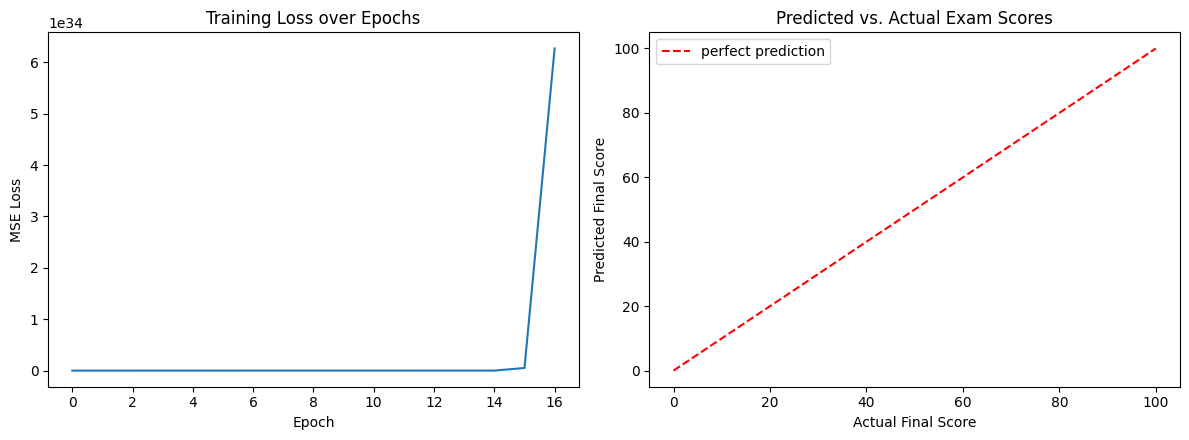

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(losses)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Loss over Epochs")

with torch.no_grad():
    predicted = model(X).numpy().flatten()

axes[1].scatter(Y.numpy().flatten(), predicted, alpha=0.5)
lims = [0, 100]
axes[1].plot(lims, lims, color="red", linestyle="--", label="perfect prediction")
axes[1].set_xlabel("Actual Final Score")
axes[1].set_ylabel("Predicted Final Score")
axes[1].set_title("Predicted vs. Actual Exam Scores")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Working with Datasets: `TensorDataset` & `DataLoader`

Real learning-analytics pipelines process thousands of student records in **mini-batches**, shuffled every epoch so the model doesn't pick up on artifacts of row ordering (e.g. records sorted by cohort or enrollment date).

We'll build a richer **Student Performance dataset** with 5 features per student, ready to feed into a neural network in the next sections.


In [16]:
np.random.seed(1)
n = 800

gpa = np.clip(np.random.normal(2.8, 0.7, n), 0.0, 4.0)
attendance_pct = np.clip(np.random.normal(80, 15, n), 0, 100)
study_hours = np.clip(np.random.normal(8, 5, n), 0, 30)
lms_engagement = np.clip(np.random.normal(55, 25, n), 0, 100)     # logins/activity score
extracurricular = np.random.binomial(1, 0.35, n)                  # participates: 0/1

student_features_df = pd.DataFrame({
    "GPA": gpa,
    "Attendance (%)": attendance_pct,
    "Study Hours/Week": study_hours,
    "LMS Engagement Score": lms_engagement,
    "Extracurricular": extracurricular,
})
student_features_df.head()


,GPA,Attendance (%),Study Hours/Week,LMS Engagement Score,Extracurricular
0,3.937042,92.215147,9.455023,48.112973,1
1,2.371771,91.707049,13.374499,83.476332,0
2,2.430280,58.039196,4.510950,99.106239,0
3,2.048922,77.682632,5.108371,55.189010,0
4,3.405785,78.613515,3.762737,62.368488,0


In [17]:
features = student_features_df.values
# Dummy placeholder target for the DataLoader demo (real targets built per-project below)
dummy_target = (student_features_df["GPA"] > 2.5).astype(int).values

student_dataset = TensorDataset(
    torch.tensor(features, dtype=torch.float32),
    torch.tensor(dummy_target, dtype=torch.long)
)

student_loader = DataLoader(student_dataset, batch_size=32, shuffle=True)

for batch_idx, (batch_features, batch_targets) in enumerate(student_loader):
    print(f"Batch {batch_idx + 1}")
    print("Features shape:", batch_features.shape)
    print("Targets:", batch_targets[:10], "...")
    break


Batch 1
Features shape: torch.Size([32, 5])
Targets: tensor([1, 1, 0, 1, 1, 1, 1, 1, 0, 0]) ...


## 8. Building a Neural Network with `nn.Module`

Every custom PyTorch model:
- Calls `super().__init__()`, then defines layers as attributes in `__init__` (auto-registers parameters).
- Implements `forward(self, x)` to define the data flow.
- Is always invoked as `model(x)`, never `model.forward(x)` directly, so PyTorch's hooks and train/eval mode switching work correctly.

We'll design a classifier for **student dropout risk**: 5 behavioral/academic features → 2 classes (*Retained* / *At risk of dropout*).


In [18]:
class DropoutRiskClassifier(nn.Module):
    def __init__(self, input_features, hidden1, hidden2, output_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, output_classes)

    def forward(self, x):
        a1 = F.relu(self.fc1(x))
        a2 = F.relu(self.fc2(a1))
        output = self.out(a2)   # raw logits; CrossEntropyLoss applies softmax internally
        return output


## 9. Project 2 — Student Dropout Prediction

**Trending topic:** early identification of **at-risk students** is one of the most active applications of AI in education — used by universities to trigger advisor outreach, tutoring referrals, and financial-aid check-ins *before* a student withdraws.

We'll build a labeled version of the dataset above: lower GPA, poor attendance, low study hours, and low LMS engagement each push risk of dropout up.


In [19]:
np.random.seed(7)
n = 1000

gpa = np.clip(np.random.normal(2.7, 0.8, n), 0.0, 4.0)
attendance_pct = np.clip(np.random.normal(78, 18, n), 0, 100)
study_hours = np.clip(np.random.normal(7, 5, n), 0, 30)
lms_engagement = np.clip(np.random.normal(50, 27, n), 0, 100)
extracurricular = np.random.binomial(1, 0.35, n)

# Latent "risk score": higher = more likely to drop out. Combine signals + noise.
risk_score = (
    -1.1 * (gpa - 2.5)
    -0.03 * (attendance_pct - 75)
    -0.04 * (study_hours - 8)
    -0.02 * (lms_engagement - 50)
    -0.3 * extracurricular
    + np.random.normal(0, 0.6, n)
)
dropout = (risk_score > 0.15).astype(int)   # 1 = at risk of dropout, 0 = retained

dropout_df = pd.DataFrame({
    "GPA": gpa, "Attendance (%)": attendance_pct, "Study Hours/Week": study_hours,
    "LMS Engagement Score": lms_engagement, "Extracurricular": extracurricular,
    "Dropout": dropout
})
print("Class balance:\n", dropout_df["Dropout"].value_counts(normalize=True))
dropout_df.head()


Class balance:
 Dropout
0    0.629
1    0.371
Name: proportion, dtype: float64


,GPA,Attendance (%),Study Hours/Week,LMS Engagement Score,Extracurricular,Dropout
0,4.000000,93.927983,6.622201,96.447801,0,0
1,2.327250,61.635872,9.544716,53.841018,1,0
2,2.726256,98.435714,3.015315,50.904180,0,0
3,3.026013,79.563323,9.605782,15.969583,0,1
4,2.068862,91.530014,5.471258,58.378807,0,0


In [20]:
torch.manual_seed(42)

X = dropout_df.drop(columns="Dropout").values
y = dropout_df["Dropout"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features (helps optimization converge faster/more reliably)
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

model = DropoutRiskClassifier(input_features=X_train.shape[1], hidden1=16, hidden2=8, output_classes=2)
print(model)


DropoutRiskClassifier(
  (fc1): Linear(in_features=5, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=2, bias=True)
)


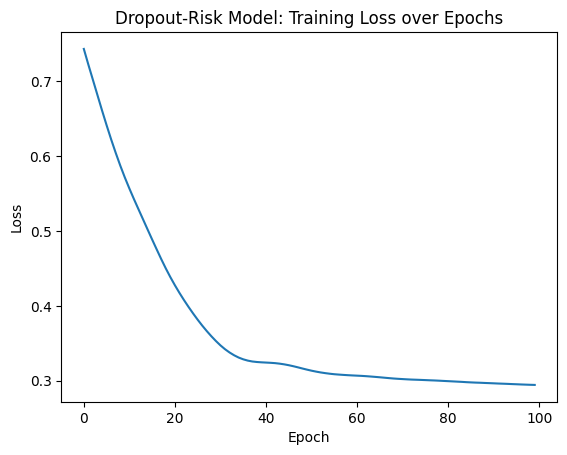

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
training_losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X_train)
    loss = criterion(predictions, y_train)
    loss.backward()
    optimizer.step()
    training_losses.append(loss.item())

plt.plot(training_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout-Risk Model: Training Loss over Epochs")
plt.show()


In [22]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probs = torch.softmax(test_logits, dim=1)[:, 1]   # probability of "at risk"
    predicted_labels = torch.argmax(test_logits, dim=1)

accuracy = (predicted_labels == y_test).float().mean().item() * 100
print(f"Test accuracy: {accuracy:.2f}%")

# Simple confusion matrix
tp = ((predicted_labels == 1) & (y_test == 1)).sum().item()
tn = ((predicted_labels == 0) & (y_test == 0)).sum().item()
fp = ((predicted_labels == 1) & (y_test == 0)).sum().item()
fn = ((predicted_labels == 0) & (y_test == 1)).sum().item()
print(f"TP={tp}  FN={fn}  FP={fp}  TN={tn}")
precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
print(f"Precision (of flagged students, % truly at risk): {precision*100:.1f}%")
print(f"Recall (of truly at-risk students, % caught): {recall*100:.1f}%")


Test accuracy: 82.50%
TP=60  FN=14  FP=21  TN=105
Precision (of flagged students, % truly at risk): 74.1%
Recall (of truly at-risk students, % caught): 81.1%


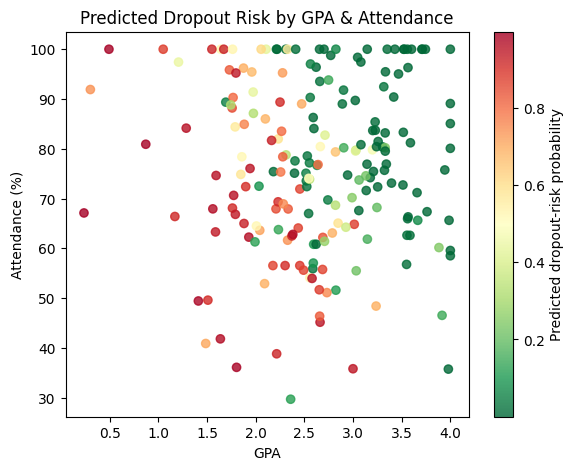

In [23]:
# Visualize predicted at-risk probability vs. GPA and attendance
X_test_np = X_test.numpy() * X_std + X_mean   # de-standardize for interpretable axes
plt.figure(figsize=(6.5, 5))
sc = plt.scatter(X_test_np[:, 0], X_test_np[:, 1], c=test_probs.numpy(), cmap="RdYlGn_r", alpha=0.8)
plt.colorbar(sc, label="Predicted dropout-risk probability")
plt.xlabel("GPA")
plt.ylabel("Attendance (%)")
plt.title("Predicted Dropout Risk by GPA & Attendance")
plt.show()


**Why this matters:** `precision` tells advisors how much of their outreach effort targets genuinely at-risk students (avoiding wasted interventions), while `recall` tells them what fraction of at-risk students they'd actually catch. Real retention programs tune the decision threshold to balance these trade-offs.

## 10. Project 3 — Challenge: Student Performance-Level Classification

**Trending topic: adaptive / personalized learning.** Instead of a single score, many platforms bucket students into **performance tiers** (Low / Medium / High) to route them to the right difficulty level, content pacing, or support resources.

This mirrors the workflow of Project 2 but as a **3-class** problem — confirm you can reproduce the full pipeline independently: build data → split → tensors → model → train → evaluate → visualize.


In [24]:
np.random.seed(3)
n = 900

study_hours = np.clip(np.random.normal(9, 5, n), 0, 30)
attendance = np.clip(np.random.normal(80, 15, n), 0, 100)
prior_grade = np.clip(np.random.normal(70, 15, n), 0, 100)
participation = np.clip(np.random.normal(60, 20, n), 0, 100)

# Composite academic score -> tiered into 3 performance levels
composite = 0.3*study_hours*5 + 0.25*attendance + 0.30*prior_grade + 0.15*participation
composite += np.random.normal(0, 8, n)

# Discretize into terciles: 0 = Low, 1 = Medium, 2 = High
thresholds = np.quantile(composite, [1/3, 2/3])
performance_level = np.digitize(composite, thresholds)

perf_df = pd.DataFrame({
    "Study Hours/Week": study_hours, "Attendance (%)": attendance,
    "Prior Grade (%)": prior_grade, "Participation Score": participation,
    "Performance Level": performance_level  # 0=Low, 1=Medium, 2=High
})
print(perf_df["Performance Level"].value_counts().sort_index())
perf_df.head()


Performance Level
0    300
1    300
2    300
Name: count, dtype: int64


,Study Hours/Week,Attendance (%),Prior Grade (%),Participation Score,Performance Level
0,17.943142,83.345212,43.229552,80.587670,2
1,11.182549,90.885937,59.399422,77.325588,1
2,9.482487,79.709329,84.370565,60.370187,1
3,0.000000,91.664346,86.971716,33.509789,0
4,7.613059,98.971063,64.445212,81.102869,2


In [25]:
torch.manual_seed(42)

X = perf_df.drop(columns="Performance Level").values
y = perf_df["Performance Level"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)


class PerformanceLevelModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


input_size = X.shape[1]
output_size = len(np.unique(y))   # 3 tiers
model_perf = PerformanceLevelModel(input_size=input_size, hidden_size=16, output_size=output_size)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_perf.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model_perf(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

model_perf.eval()
with torch.no_grad():
    y_test_pred = model_perf(X_test_tensor)
    y_test_pred_labels = torch.argmax(y_test_pred, dim=1)

accuracy = (y_test_pred_labels == y_test_tensor).sum().item() / len(y_test) * 100
print(f"\nTest accuracy: {accuracy:.2f}%")


Epoch 0, Loss: 1.0785


Epoch 20, Loss: 0.8164
Epoch 40, Loss: 0.7902
Epoch 60, Loss: 0.7771
Epoch 80, Loss: 0.7702

Test accuracy: 60.56%


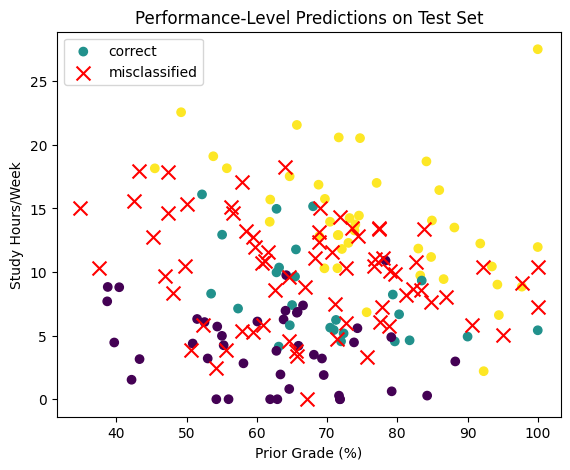

Legend: 0 = Low | 1 = Medium | 2 = High


In [26]:
# Visualize predictions vs. ground truth on two informative features
labels = {0: "Low", 1: "Medium", 2: "High"}
X_test_display = X_test * X_std + X_mean   # de-standardize for interpretable axes

correct = (y_test_pred_labels == y_test_tensor).numpy()
plt.figure(figsize=(6.5, 5))
sc = plt.scatter(X_test_display[correct, 2], X_test_display[correct, 0],
                  c=y_test[correct], cmap="viridis", label="correct", marker="o")
plt.scatter(X_test_display[~correct, 2], X_test_display[~correct, 0],
            c="red", marker="x", s=100, label="misclassified")
plt.xlabel("Prior Grade (%)")
plt.ylabel("Study Hours/Week")
plt.title("Performance-Level Predictions on Test Set")
plt.legend()
plt.show()

print("Legend: 0 =", labels[0], "| 1 =", labels[1], "| 2 =", labels[2])


## 11. Wrap-up & Key Takeaways

- **Tensors** naturally represent student records: a vector per student, a matrix per class/cohort, a 3D tensor for time-series engagement logs.
- **`torch.zeros/ones/arange/linspace/rand/randn/randint`** cover initializing gradebooks, semester schedules, grading curves, and model weights.
- **`view`/`reshape`/`unsqueeze`/`squeeze`** turn flat LMS exports into the `(students, features)` shape models expect.
- **Autograd** automatically computes how each model parameter should change to reduce prediction error — the same math whether predicting exam scores or flagging at-risk students.
- **The training loop** is always: `forward → loss → zero_grad → backward → step`.
- **`nn.Module`** organizes any model — from a two-feature linear regressor to a multi-layer dropout-risk classifier.
- **`TensorDataset` + `DataLoader`** batch and shuffle thousands of student records efficiently.
- **`model.eval()` + `torch.no_grad()`** are essential for trustworthy, efficient inference once a model is deployed.

### From notebook to real institution

To adapt these projects to a real deployment, you'd:
1. Replace synthetic data with de-identified LMS/SIS exports (attendance systems, gradebooks, engagement logs).
2. Add fairness and bias audits — dropout/performance models can unintentionally encode socioeconomic or demographic bias if not checked carefully.
3. Calibrate the decision threshold using precision/recall trade-offs relevant to the intervention's cost (e.g. an advising call is cheap; a scholarship reallocation is not).
4. Continuously retrain as cohorts and curricula change — a model trained on last year's students can drift.

The underlying PyTorch mechanics — tensors, autograd, `nn.Module`, and the training loop — stay exactly the same across all of these real-world extensions.
